In [ ]:
# Import all libraries needed:
# - pandas/numpy/seaborn/matplotlib for data handling
# - sklearn for preprocessing, models, train/test split, and metrics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [ ]:
# load dataset
df = pd.read_csv("/content/abalone.data.csv")


In [ ]:
df.head()

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [ ]:
df.isnull().sum()

,0
gender,0
Length,0
Diameter,0
Height,0
Whole weight,0
Shucked weight,0
Viscera weight,0
Shell weight,0
Rings,0


In [ ]:
# Create the target column: Age = Rings + 1.5 (per the task instructions)
df["Age"] = df["Rings"] + 1.5

# Confirm the new column was added correctly
df[["Rings", "Age"]].head()

,Rings,Age
0,15,16.5
1,7,8.5
2,9,10.5
3,10,11.5
4,7,8.5


In [ ]:
# Define input features (X) and target (y)
# gender is categorical, the rest are numeric physical measurements
NUMERIC_FEATURES = ["Length", "Diameter", "Height",
                     "Whole weight", "Shucked weight", "Viscera weight", "Shell weight"]
CATEGORICAL_FEATURES = ["gender"]
ALL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

X = df[ALL_FEATURES]
y = df["Age"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (4177, 8)
Target vector shape: (4177,)


/tmp/ipykernel_20494/16496439.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gender", y="Age", palette="Set2")


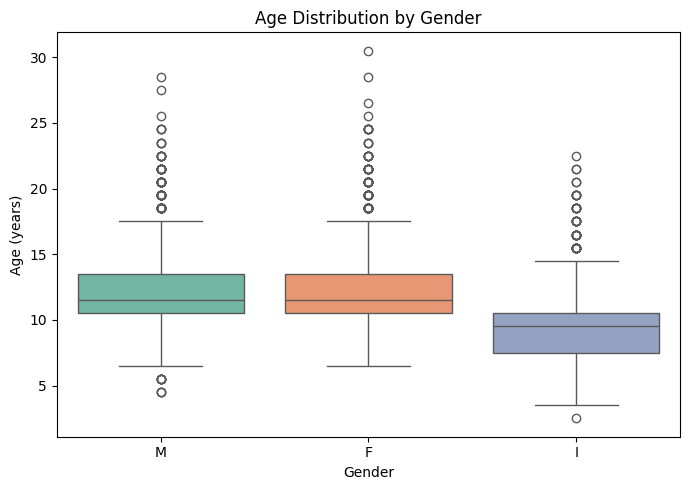

In [ ]:
# Boxplot: Age distribution by gender
# Meaningful because it shows whether Infants (I) are genuinely younger than
# Males/Females, and reveals outliers (unusually old/young abalones) per group
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="gender", y="Age", palette="Set2")
plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

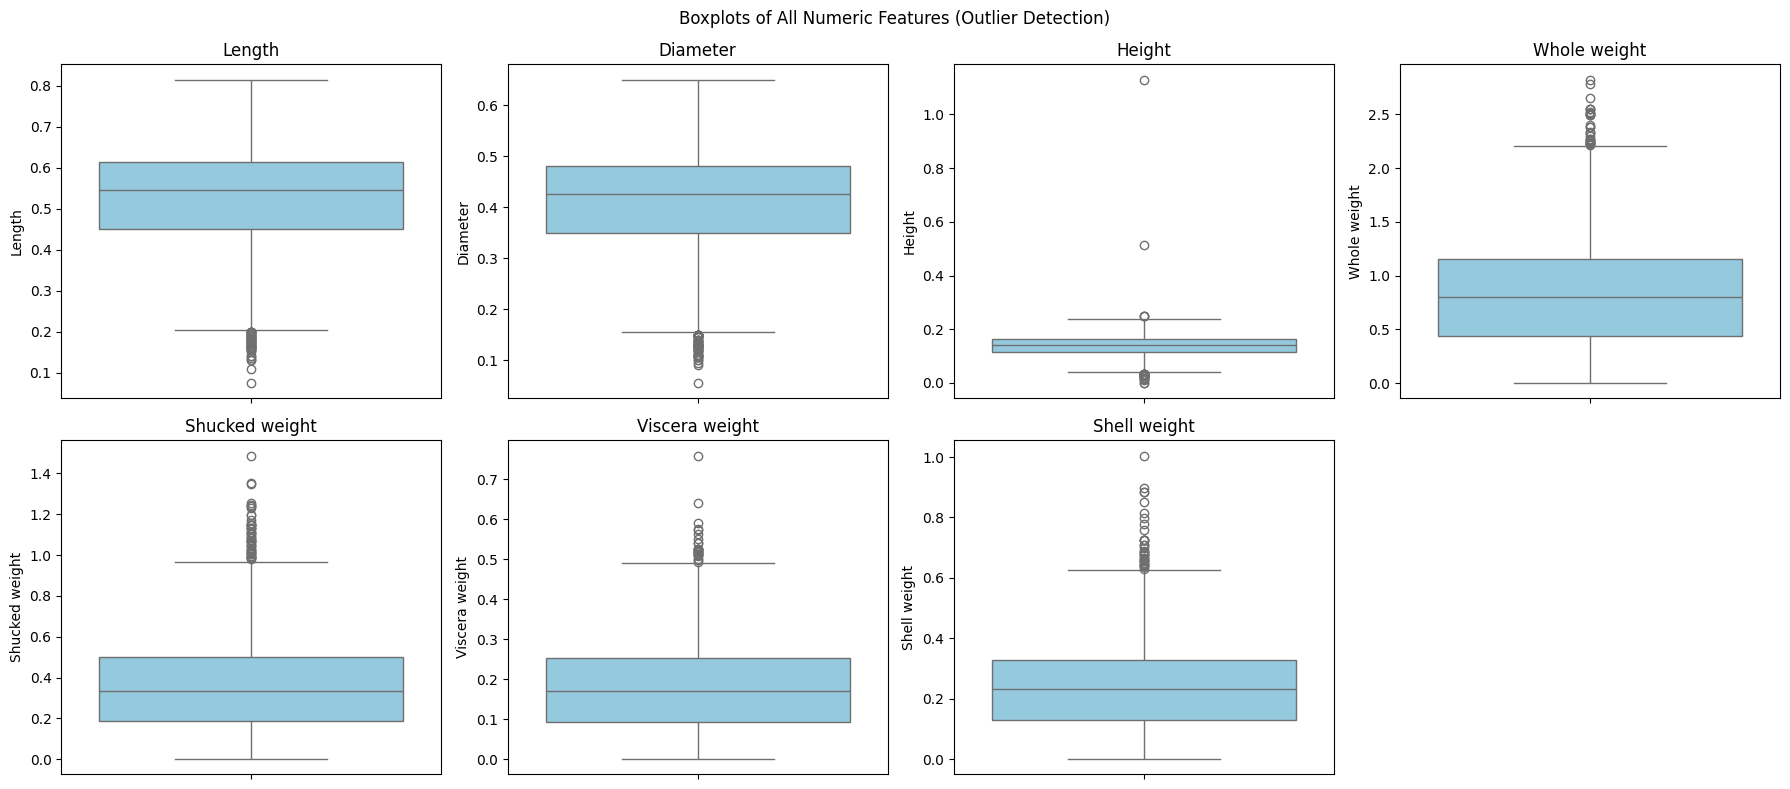

In [ ]:
# Boxplots for all numeric measurements
# Meaningful because it detects outliers in each feature at a glance
# (points beyond the whiskers are potential data errors or unusual specimens)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, NUMERIC_FEATURES + ["Age"]):
    sns.boxplot(data=df, y=col, ax=ax, color="skyblue")
    ax.set_title(col)
fig.delaxes(axes[-1])  # 7 features + Age = 8 slots used, last one unused
plt.suptitle("Boxplots of All Numeric Features (Outlier Detection)")
plt.tight_layout()
plt.show()

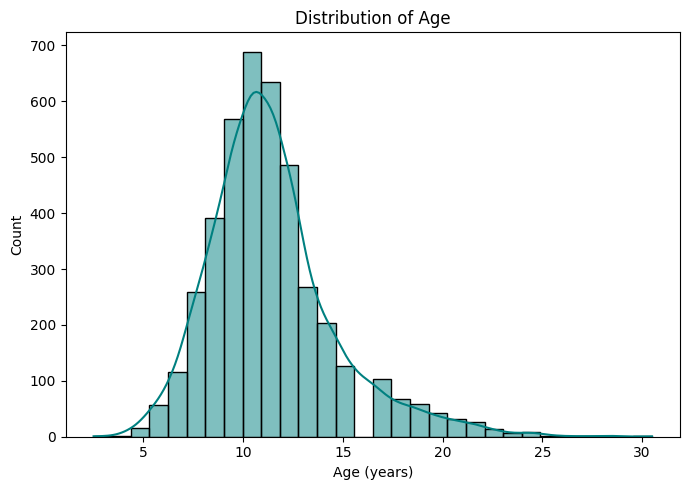

In [ ]:
# Histogram: overall Age distribution
# Meaningful because it shows the target is right-skewed (most abalones are
# young, a long tail of older ones) which explains why models tend to
# underpredict the oldest abalones
plt.figure(figsize=(7, 5))
sns.histplot(df["Age"], bins=30, kde=True, color="teal")
plt.title("Distribution of Age")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

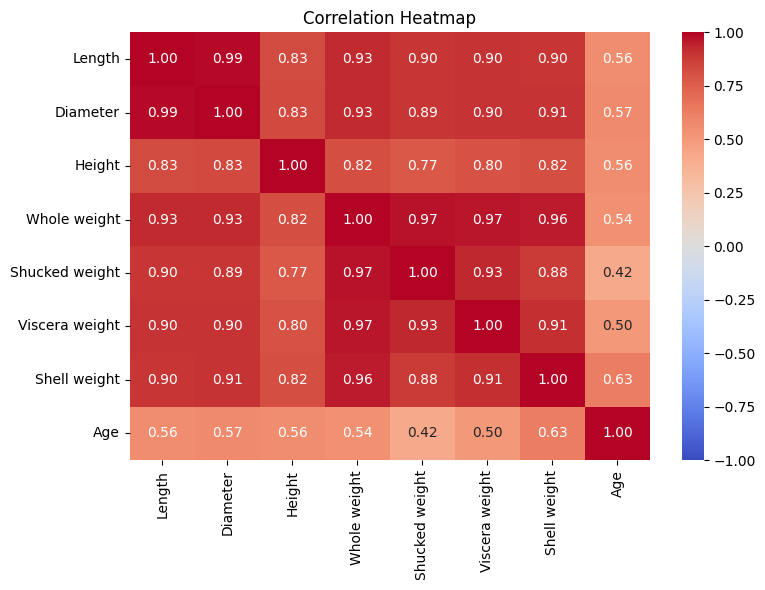

In [ ]:
# Correlation heatmap (visual version of the corr_df table)
# Meaningful because it instantly highlights redundant/highly correlated
# features (dark red), which matters especially for Linear Regression
plt.figure(figsize=(8, 6))
sns.heatmap(df[NUMERIC_FEATURES + ["Age"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

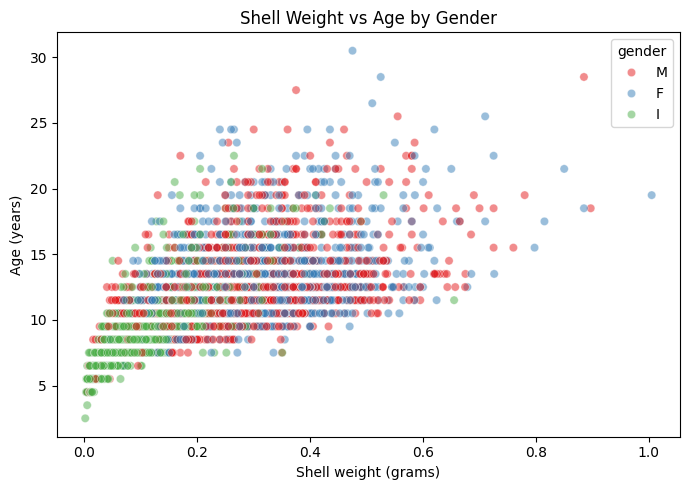

In [ ]:
# Scatter plot: Shell weight vs Age, colored by gender
# Meaningful because Shell weight has the strongest correlation with Age (0.63)
# among all features, so this shows the clearest single-feature relationship
# and whether it differs by gender
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Shell weight", y="Age", hue="gender", alpha=0.5, palette="Set1")
plt.title("Shell Weight vs Age by Gender")
plt.xlabel("Shell weight (grams)")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

In [ ]:
# Split the data into training (80%) and testing (20%) sets
# random_state=42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3341
Testing samples: 836


In [ ]:
# Build a preprocessor that one-hot encodes the categorical "gender" column
# and passes the numeric columns through unchanged
preprocessor = ColumnTransformer(
    transformers=[("gender", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)],
    remainder="passthrough"
)

In [ ]:
# Define the 3 regression models, each wrapped with the preprocessor in a Pipeline
# so raw input (including gender text) can be fed directly to .fit()/.predict()
models = {
    "Linear Regression": Pipeline([
        ("prep", preprocessor),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
}

list(models.keys())

['Linear Regression', 'Random Forest', 'Gradient Boosting']

In [ ]:
# Train each model and evaluate it using 5 metrics:
# R2   - proportion of variance explained (higher is better, max 1.0)
# RMSE - root mean squared error, in years (lower is better)
# MAE  - mean absolute error, in years (lower is better)
# MSE  - mean squared error, in years^2 (lower is better)
# MAPE - mean absolute percentage error (lower is better)

results = []
predictions = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    predictions[name] = preds

    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "MAPE": mape
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df

,R2,RMSE,MAE,MSE,MAPE
Model,,,,,
Linear Regression,0.548163,2.211613,1.593107,4.891232,0.137252
Random Forest,0.534837,2.243989,1.578983,5.035487,0.132867
Gradient Boosting,0.531281,2.252550,1.577067,5.073981,0.132167


In [ ]:
# Redundancy check: correlation matrix of numeric features + Age
# Values close to 1.0 or -1.0 indicate two features carry almost the same information
corr_df = df[NUMERIC_FEATURES + ["Age"]].corr()
corr_df.round(2)

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Age
Length,1.00,0.99,0.83,0.93,0.90,0.90,0.90,0.56
Diameter,0.99,1.00,0.83,0.93,0.89,0.90,0.91,0.57
Height,0.83,0.83,1.00,0.82,0.77,0.80,0.82,0.56
Whole weight,0.93,0.93,0.82,1.00,0.97,0.97,0.96,0.54
Shucked weight,0.90,0.89,0.77,0.97,1.00,0.93,0.88,0.42
Viscera weight,0.90,0.90,0.80,0.97,0.93,1.00,0.91,0.50
Shell weight,0.90,0.91,0.82,0.96,0.88,0.91,1.00,0.63
Age,0.56,0.57,0.56,0.54,0.42,0.50,0.63,1.00


In [ ]:
# Redundancy check: Variance Inflation Factor (VIF) per numeric feature
# VIF > 5-10 signals that a feature is highly redundant with the others
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(df[NUMERIC_FEATURES])
vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df

,feature,VIF
0,Whole weight,109.592750
1,Diameter,41.845452
2,Length,40.771813
3,Shucked weight,28.353191
4,Shell weight,21.258289
5,Viscera weight,17.346276
6,Height,3.559939


In [ ]:
# Ask the user for abalone measurements, then predict Age with all 3 trained models
def get_user_input():
    gender = input("Gender (M/F/I): ").strip().upper()
    length = float(input("Length (mm, e.g. 0.455): "))
    diameter = float(input("Diameter (mm, e.g. 0.365): "))
    height = float(input("Height (mm, e.g. 0.095): "))
    whole_w = float(input("Whole weight (grams, e.g. 0.514): "))
    shucked_w = float(input("Shucked weight (grams, e.g. 0.2245): "))
    viscera_w = float(input("Viscera weight (grams, e.g. 0.101): "))
    shell_w = float(input("Shell weight (grams, e.g. 0.15): "))

    return pd.DataFrame([{
        "gender": gender, "Length": length, "Diameter": diameter, "Height": height,
        "Whole weight": whole_w, "Shucked weight": shucked_w,
        "Viscera weight": viscera_w, "Shell weight": shell_w
    }])

sample = get_user_input()

for name, pipe in models.items():
    pred_age = pipe.predict(sample)[0]
    print(f"{name:<20} -> Predicted Age: {pred_age:.2f} years")

Gender (M/F/I): M
Length (mm, e.g. 0.455): 0.33
Diameter (mm, e.g. 0.365): 0.44
Height (mm, e.g. 0.095): 0.55
Whole weight (grams, e.g. 0.514): 0.77
Shucked weight (grams, e.g. 0.2245): 0.99
Viscera weight (grams, e.g. 0.101): 0.32
Shell weight (grams, e.g. 0.15): 0.12
Linear Regression    -> Predicted Age: 0.74 years
Random Forest        -> Predicted Age: 10.46 years
Gradient Boosting    -> Predicted Age: 8.41 years
